# Download and prepare `SW_IN` (2004-2025)

**notebook version**: `7` (20 Jul 2026)

## ℹ️ About this notebook

Downloads screened `SW_IN` from InfluxDB, merges the three sources into one continuous series,
corrects the 2012 logger faults and the nighttime sensor offset, gap-fills, and writes the product
to the external data folder.

**Output columns:**

- `SW_IN_T1_47_1_gfXG` — the gap-filled series (W m⁻², complete, non-negative)
- `FLAG_SW_IN_T1_47_1_ISFILLED` — `0` = measured, `>0` = filled (codes in `FLAG_LEGEND` below)

**Fill quality is not uniform.** 2004-2018 has two radiation drivers, NABEL on the same tower and
MeteoSwiss Lägern 2.5 km away; 2019-2025 has only Lägern. Both are filled from real measurements,
but the later period leans on the more distant sensor.

Downloading uses diive's `InfluxIO`, which needs `influxdb-client`; `uv sync` installs it here via
the `diive[db]` extra.

***

## 📇 Data sources

**Series**

- `SW_IN_T1_47_1` — ETH, 47 m. **This is the product series.** mst (2005-2021), diive (2022-2025)
- `SW_IN_NABEL_T1_49_1` — NABEL, 49 m, same tower. 2004-2018 only. Gap-filling driver
- `SW_IN_LAE_MS` — MeteoSwiss Lägern, 2.5 km, 845 m. 2004-2025. Gap-filling driver, read from
  the product written by `10_REFERENCE/MeteoSwiss_LAE_2004-2025.ipynb`

Both drivers are used as measured. Gap-filling is XGBoost; potential radiation and timestamp
features are added by the gap-filler itself.

**Legend**

- NABEL ... [NABEL](https://www.bafu.admin.ch/bafu/en/home/topics/air/luftbelastung/national-air-pollution-monitoring-network--nabel-.html), meteoscreening with [diive](https://github.com/holukas/diive)
- mst ... ETH data, meteoscreening with the now deprecated MeteoscreeningTool
- diive ... ETH data, meteoscreening with diive

## ⏱️ Timestamp convention

The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`**. On download, `InfluxIO`
shifts the UTC timestamp by `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the returned data are in **local
time** (UTC + offset) and still `TIMESTAMP_END`. `TimestampSanitizer(output_middle_timestamp=True)`
then converts to `TIMESTAMP_MID`, which is what the rest of this notebook works with.

`START` and `STOP` are interpreted in the same timezone as `TIMEZONE_OFFSET_TO_UTC_HOURS`.

***

## ⚙️ Settings

### Data settings

In [1]:
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configuration files: needed e.g. for connection to database
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # Timezone, e.g. "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'  # Expected resolution; TimestampSanitizer raises if the data disagree
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

# Output: data files live in the external (untracked) data folder, with the same
# numeric prefix as this notebook.
OUTNAME = "01_METEO_SW_IN_GAPFILLED_2004-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"

# Reference: MeteoSwiss Lägern, 2.5 km from the tower on the same ridge. Produced by
# 10_REFERENCE/MeteoSwiss_LAE_2004-2025.ipynb. Addressed by path, so a move breaks this read.
REFPATH = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
           r"\workflow\10_METEO\10_REFERENCE\MeteoSwiss_LAE_30MIN_2004-2025.parquet")
REFCOL = "SW_IN_LAE_MS"

### Imports

In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv
from diive.core.io.db.influx import InfluxIO  # diive's in-house InfluxDB engine (via the diive[db] extra)
from diive.core.times.times import TimestampSanitizer

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

# Start time is kept so the last cell can report the total runtime of the notebook.
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-07-20 22:55:29
diive version: v0.91.0


In [3]:
# Result flags of SWINGapFillerXGBoost, see the class docstring.
FLAG_LEGEND = {
    0: '0 = observed',
    1: '1 = daytime gap, filled by the XGBoost model',
    2: '2 = daytime gap, filled by the timestamp-only fallback model (a driver was missing)',
    3: '3 = nighttime gap, set to zero by physics',
    4: '4 = daytime gap, filled by clearness-index interpolation',
}

### Plot helpers

In [4]:
# Diagnostic plots for the gap-filling runs. Defined once, used after every run.

def plot_gapfill_panels(results, title, ylabel=r'$\mathrm{W\ m^{-2}}$', figsize=(16, 7)):
    """Three stacked panels: measured only, the final series, and the fills on their own.

    The third panel is the one to look at. Fills are shown against a blank background, so
    a fill that sits at the wrong level, or a block of fills where there should be none,
    is immediately visible instead of being hidden under the measured series.
    """
    gapfilled = results.gapfilled
    flag = results.flag
    _plotdf = pd.DataFrame({
        'observed': gapfilled.where(flag == 0),
        'gapfilled': gapfilled,
        'gap values': gapfilled.where(flag > 0),
    })
    axs = _plotdf.plot(subplots=True, figsize=figsize, x_compat=True, alpha=.9,
                       title=title, legend=True)
    for ax in axs:
        ax.set_ylabel(ylabel)
    plt.tight_layout()
    return axs


def fill_stats_by_year(flag, legend=None):
    """Records per year and flag, plus a stacked bar chart of the filled ones."""
    legend = legend or FLAG_LEGEND
    tab = (pd.crosstab(flag.index.year, flag)
             .rename(columns=lambda f: legend.get(f, f))
             .rename_axis(index='year', columns=None))
    filled = tab.drop(columns=[c for c in tab.columns if str(c).startswith('0 =')],
                      errors='ignore')
    if not filled.empty and filled.to_numpy().sum() > 0:
        ax = filled.plot(kind='bar', stacked=True, figsize=(14, 4),
                         title='Filled records per year')
        ax.set_ylabel('records')
        ax.legend(fontsize=8)
        plt.tight_layout()
    return tab


def plot_fill_overview(series, flag, label, ylabel=r'$\mathrm{W\ m^{-2}}$'):
    """Four-panel overview of the final series: where the fills are and how they behave.

    Panels: flag over date/time-of-day; monthly means of the full series against the
    measured-only series (a gap between the two lines means the fills are biased);
    cumulative sum; and the share of filled records per month.
    """
    fig = plt.figure(figsize=(18, 9), dpi=100, layout='constrained')
    gs = gridspec.GridSpec(2, 2, figure=fig)
    fig.suptitle(f'Gap-filling overview: {label}', fontsize=15)

    ax = fig.add_subplot(gs[:, 0])
    dv.plotting.HeatmapDateTime(series=flag.astype(float)).plot(
        ax=ax, cb_digits_after_comma=0, zlabel='flag',
        format_style=dv.plotting.FormatStyle(title='Flag (0 = measured)', title_fontsize=11))

    measured = series.where(flag == 0)
    ax = fig.add_subplot(gs[0, 1])
    series.resample('MS').mean().plot(ax=ax, label='all records', lw=1.2)
    measured.resample('MS').mean().plot(ax=ax, label='measured only', lw=1.2, ls='--')
    ax.set_title('Monthly means', fontsize=11)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

    ax = fig.add_subplot(gs[1, 1])
    share = (flag > 0).resample('MS').mean() * 100
    ax.fill_between(share.index, share.values, step='mid', alpha=.7)
    ax.set_title('Share of filled records per month', fontsize=11)
    ax.set_ylabel('%')
    return fig


def plot_pred_vs_measured(model, title, unit=r'$\mathrm{W\ m^{-2}}$'):
    """Predicted against measured on the HELD-OUT test set, plus residuals.

    This is the only honest validation view available: `gapfilled` equals the measurement
    wherever the flag is 0, so plotting those against each other would just draw the 1:1
    line. `daytime_model_.traintest_details_` keeps the test records the model never saw
    during training, which is what these panels use.

    Left: measured vs predicted, 1:1 line in red. Right: residual against prediction —
    a tilt means bias, a widening cone means the error scales with magnitude.
    """
    if model is None:
        print("No model available (no daytime gaps) - nothing to validate.")
        return
    test = model.traintest_details_['test_df']
    measured = test[model.target_col].values
    predicted = model.model_.predict(test.drop(columns=model.target_col))
    residual = predicted - measured
    rmse = float(np.sqrt((residual ** 2).mean()))
    bias = float(residual.mean())

    fig, axs = plt.subplots(ncols=2, figsize=(13, 5.5), dpi=100, layout='constrained')
    fig.suptitle(f"{title}  (held-out test set, n={len(test):,})", fontsize=13)

    axs[0].hexbin(measured, predicted, gridsize=60, mincnt=1, bins='log', cmap='viridis')
    lim = [float(min(measured.min(), predicted.min())), float(max(measured.max(), predicted.max()))]
    axs[0].plot(lim, lim, 'r-', lw=1.2, label='1:1')
    axs[0].set_xlabel(f'measured {unit}')
    axs[0].set_ylabel(f'predicted {unit}')
    axs[0].set_title(f'RMSE {rmse:.2f}   bias {bias:+.2f}', fontsize=11)
    axs[0].legend(fontsize=8)

    axs[1].hexbin(predicted, residual, gridsize=60, mincnt=1, bins='log', cmap='viridis')
    axs[1].axhline(0, color='r', lw=1.2)
    axs[1].set_xlabel(f'predicted {unit}')
    axs[1].set_ylabel(f'residual (predicted - measured) {unit}')
    axs[1].set_title('Residuals', fontsize=11)
    return fig

### 🔌 Connect to database

In [5]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

***

## ⬇️ `NABEL` data (2004-2018) and ETH data (2022-2025) from `diive` meteoscreening

### Download

In [6]:
%%time

BUCKET = f'ch-lae_processed'
FIELDS = ['SW_IN_NABEL_T1_49_1', 'SW_IN_T1_47_1']
MEASUREMENTS = ['SW']
START = '2004-01-01 00:00:01'
STOP = '2026-01-01 00:00:01'
DATA_VERSION = 'meteoscreening_diive'

nabel_eth_diive_swin_2004_2018_2022_2025, _, _ = dbc.download(
    bucket=BUCKET,
    measurements=MEASUREMENTS,
    fields=FIELDS,
    start=START,  # Download data starting with this date (the start date itself IS included),
    stop=STOP,  # Download data before this date (the stop date itself IS NOT included),
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION
)

> DOWNLOADING from bucket ch-lae_processed: variables ['SW_IN_NABEL_T1_49_1', 'SW_IN_T1_47_1'] 
from measurements ['SW'], data version ['meteoscreening_diive'], between 2004-01-01 00:00:01 and 
2026-01-01 00:00:01 (timezone offset to UTC 1)

> Downloaded data for 2 variables:

CPU times: total: 6.05 s
Wall time: 8.83 s


In [7]:
nabel_eth_diive_swin_2004_2018_2022_2025

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_END,,
2004-01-01 00:30:00,NaN,0.0
2004-01-01 01:00:00,NaN,0.0
2004-01-01 01:30:00,NaN,0.0
2004-01-01 02:00:00,NaN,0.0
2004-01-01 02:30:00,NaN,0.0
...,...,...
2025-12-31 22:00:00,0.0,NaN
2025-12-31 22:30:00,0.0,NaN
2025-12-31 23:00:00,0.0,NaN


### Sanitize timestamp

In [8]:
nabel_eth_diive_swin_2004_2018_2022_2025 = TimestampSanitizer(
    data=nabel_eth_diive_swin_2004_2018_2022_2025,
    output_middle_timestamp=True,
    nominal_freq=REQUIRED_TIME_RESOLUTION,  # raises ValueError if the data are not 30MIN
).get()
nabel_eth_diive_swin_2004_2018_2022_2025

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,0.0
2004-01-01 00:45:00,NaN,0.0
2004-01-01 01:15:00,NaN,0.0
2004-01-01 01:45:00,NaN,0.0
2004-01-01 02:15:00,NaN,0.0
...,...,...
2025-12-31 21:45:00,0.0,NaN
2025-12-31 22:15:00,0.0,NaN
2025-12-31 22:45:00,0.0,NaN


***

## ⬇️ Data from `mst` meteoscreening (2004-2021)

### Download

In [9]:
%%time

BUCKET = f'ch-lae_processed'
FIELDS = ['SW_IN_T1_47_1']
MEASUREMENTS = ['SW']
START = '2004-01-01 00:00:01'
STOP = '2022-01-01 00:00:01'
DATA_VERSION = 'meteoscreening_mst'

mst_swin_2004_2021, _, _ = dbc.download(
    bucket=BUCKET,
    measurements=MEASUREMENTS,
    fields=FIELDS,
    start=START,  # Download data starting with this date (the start date itself IS included),
    stop=STOP,  # Download data before this date (the stop date itself IS NOT included),
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION
)

> DOWNLOADING from bucket ch-lae_processed: variables ['SW_IN_T1_47_1'] from measurements ['SW'], 
data version ['meteoscreening_mst'], between 2004-01-01 00:00:01 and 2022-01-01 00:00:01 (timezone 
offset to UTC 1)

> Downloaded data for 1 variables:

CPU times: total: 4.66 s
Wall time: 6.73 s


In [10]:
mst_swin_2004_2021

,SW_IN_T1_47_1
TIMESTAMP_END,
2005-09-14 11:30:00,0.000000
2005-09-14 12:00:00,25.692612
2005-09-14 13:30:00,645.754150
2005-09-14 14:00:00,314.615936
2005-09-14 14:30:00,220.304276
...,...
2021-12-31 22:00:00,-9.935194
2021-12-31 22:30:00,-10.250348
2021-12-31 23:00:00,-9.810373


### Sanitize timestamp

In [11]:
mst_swin_2004_2021 = TimestampSanitizer(
    data=mst_swin_2004_2021,
    output_middle_timestamp=True,
    nominal_freq=REQUIRED_TIME_RESOLUTION,  # raises ValueError if the data are not 30MIN
).get()
mst_swin_2004_2021

,SW_IN_T1_47_1
TIMESTAMP_MIDDLE,
2005-09-14 11:15:00,0.000000
2005-09-14 11:45:00,25.692612
2005-09-14 12:15:00,NaN
2005-09-14 12:45:00,NaN
2005-09-14 13:15:00,645.754150
...,...
2021-12-31 21:45:00,-9.935194
2021-12-31 22:15:00,-10.250348
2021-12-31 22:45:00,-9.810373


***

## ❇️ Merge data

ETH data from `diive` meteoscreening (2022-2025) are the main data, gaps before 2022 are
filled in from the `mst` meteoscreening.

In [12]:
# Merge data on index
swin_2004_2025 = nabel_eth_diive_swin_2004_2018_2022_2025.copy()
swin_2004_2025['SW_IN_T1_47_1'] = swin_2004_2025['SW_IN_T1_47_1'].combine_first(mst_swin_2004_2021['SW_IN_T1_47_1'])
swin_2004_2025

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,0.0
2004-01-01 00:45:00,NaN,0.0
2004-01-01 01:15:00,NaN,0.0
2004-01-01 01:45:00,NaN,0.0
2004-01-01 02:15:00,NaN,0.0
...,...,...
2025-12-31 21:45:00,0.0,NaN
2025-12-31 22:15:00,0.0,NaN
2025-12-31 22:45:00,0.0,NaN


### Sanitize timestamp

In [13]:
swin_2004_2025 = TimestampSanitizer(data=swin_2004_2025, output_middle_timestamp=True).get()
swin_2004_2025

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,0.0
2004-01-01 00:45:00,NaN,0.0
2004-01-01 01:15:00,NaN,0.0
2004-01-01 01:45:00,NaN,0.0
2004-01-01 02:15:00,NaN,0.0
...,...,...
2025-12-31 21:45:00,0.0,NaN
2025-12-31 22:15:00,0.0,NaN
2025-12-31 22:45:00,0.0,NaN


### Heatmap

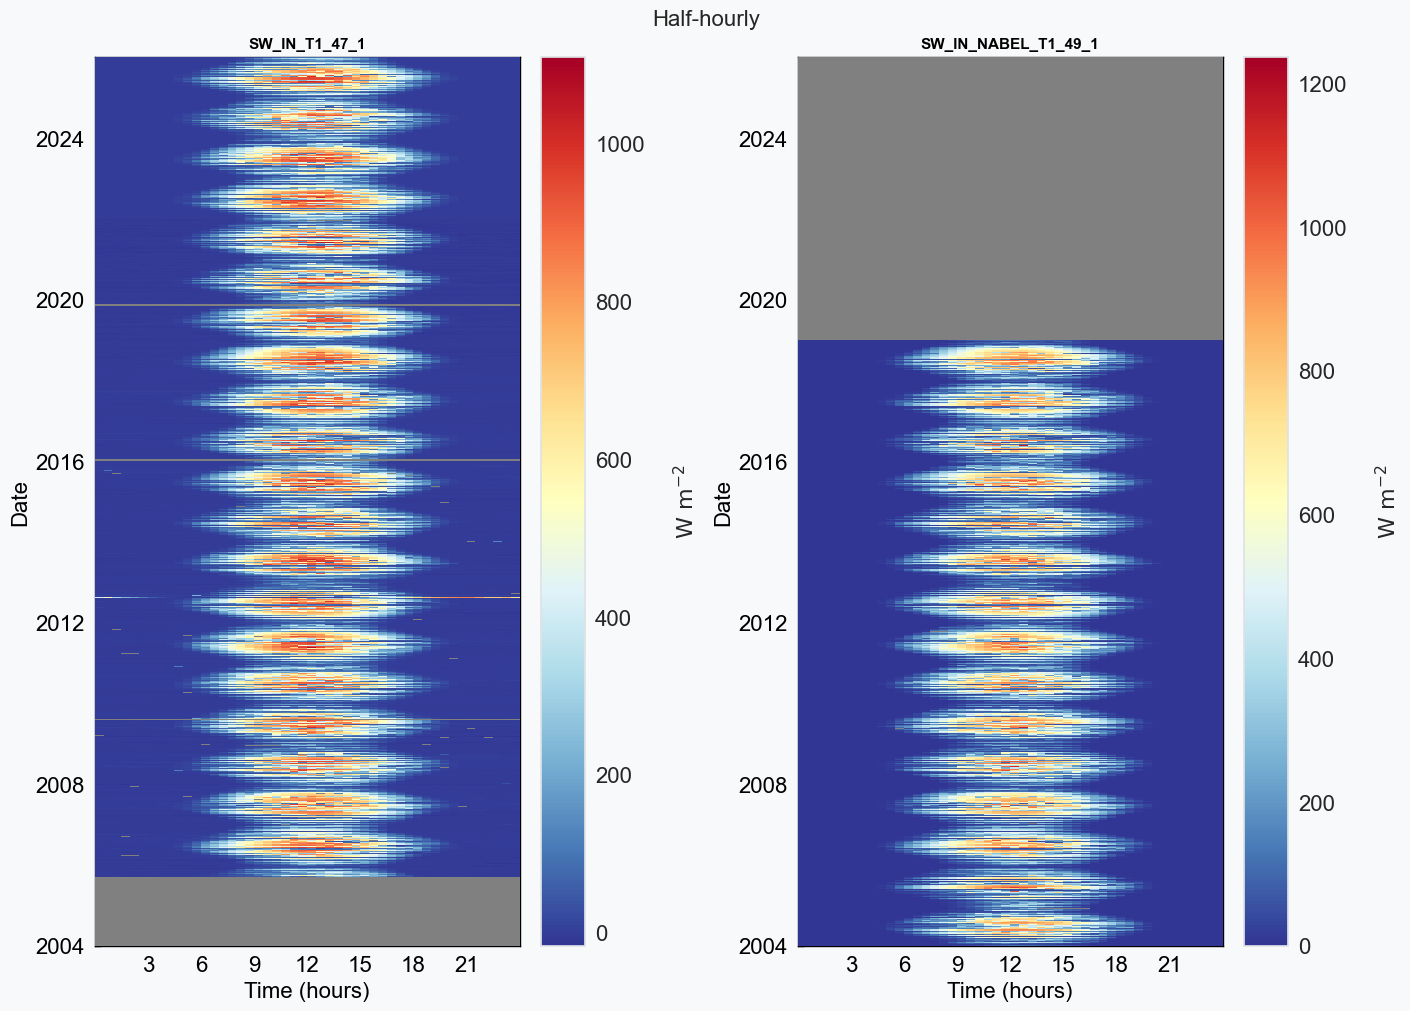

In [14]:
fig, axs = plt.subplots(ncols=2, figsize=(14, 10), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.plotting.HeatmapDateTime(series=swin_2004_2025['SW_IN_T1_47_1']).plot(
    ax=axs[0], cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
    format_style=dv.plotting.FormatStyle(title="SW_IN_T1_47_1", title_fontsize=11))
dv.plotting.HeatmapDateTime(series=swin_2004_2025['SW_IN_NABEL_T1_49_1']).plot(
    ax=axs[1], cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
    format_style=dv.plotting.FormatStyle(title="SW_IN_NABEL_T1_49_1", title_fontsize=11))

***

## ✴️ Corrections

### Timestamp shift in August 2012
**Info from fieldbook entry 17 Aug 2012:**
>   adjusted the logger date and time. On Servertime (Computer System Time) 17.08.2012 12:31.42 the loggertime was 16.08.2012 08:06:00. Synchronized time at 17.08.2012 11:40:00 servertime. The logger data aquisition on the moxa embedded was restarted

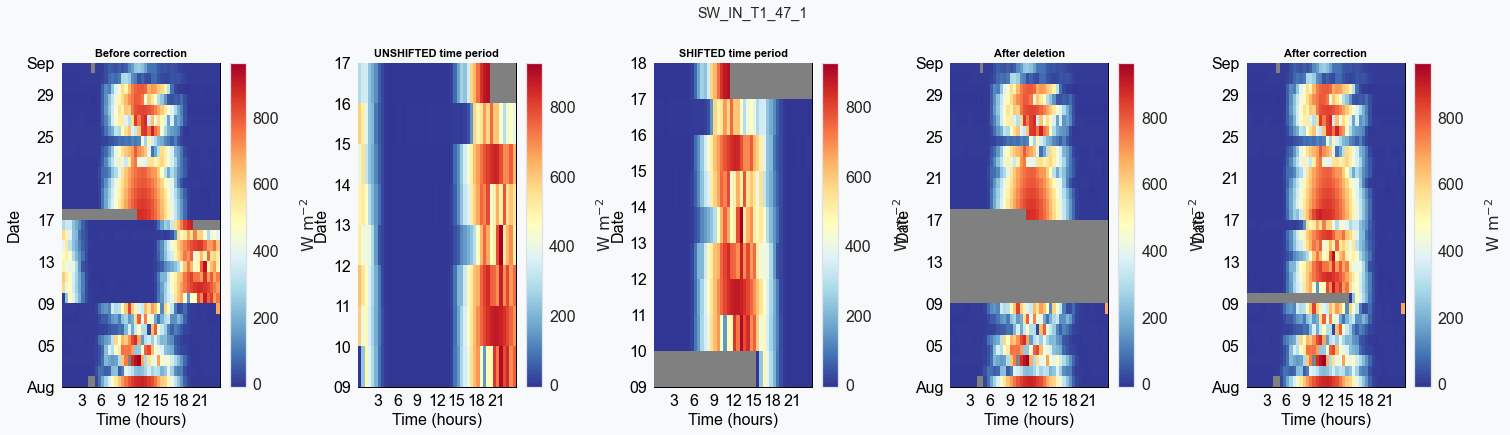

In [15]:
AFFECTED_VARS = ['SW_IN_T1_47_1']
_df = swin_2004_2025.copy()

for av in AFFECTED_VARS:
    fig = plt.figure(figsize=(24, 6), dpi=72)
    fig.suptitle(f"{av}")
    gs = gridspec.GridSpec(1, 5)  # rows, cols
    gs.update(wspace=0.5, hspace=1, left=.1, right=.9, top=.85, bottom=.1)
    ax_before = fig.add_subplot(gs[0, 0])
    ax_unshifted = fig.add_subplot(gs[0, 1])
    ax_shifted = fig.add_subplot(gs[0, 2])
    ax_after = fig.add_subplot(gs[0, 3])
    ax_corrected = fig.add_subplot(gs[0, 4])

    # Show time period around issue, before correction
    _show_locs = (_df.index >= '2012-08-01 00:00') & (_df.index <= '2012-09-01 00:00')
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_before, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title="Before correction", title_fontsize=11))

    # Get shifted time period
    _series_corrected = _df.loc[_show_locs, av].copy()
    # Identify shifted time period
    ISSUE_START = '2012-08-09 00:00'
    ISSUE_END = '2012-08-17 00:00'
    _shifted_locs = (_df.index >= ISSUE_START) & (_df.index <= ISSUE_END)
    _series_shifted = _df.loc[_shifted_locs, av].copy()
    _series_shifted = _series_shifted.dropna()
    dv.plotting.HeatmapDateTime(series=_series_shifted).plot(
        ax=ax_unshifted, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title="UNSHIFTED time period", title_fontsize=11))

    # Shift SW_IN by 15.5 hours during shifted time period, create corrected time series
    _series_shifted.index = _series_shifted.index + pd.Timedelta(hours=15.5)
    dv.plotting.HeatmapDateTime(series=_series_shifted).plot(
        ax=ax_shifted, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title="SHIFTED time period", title_fontsize=11))

    # Delete data between start of issue and the last timestamp of shifted data
    _overwrite_locs = (_df.index >= ISSUE_START) & (_df.index <= _series_shifted.index[-1])
    _df.loc[_overwrite_locs, av] = np.nan
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_after, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title="After deletion", title_fontsize=11))

    # Fill in corrected values
    _df.loc[_overwrite_locs, av] = _series_shifted
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_corrected, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title="After correction", title_fontsize=11))

In [16]:
swin_2004_2025 = _df.copy()
swin_2004_2025

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,0.0
2004-01-01 00:45:00,NaN,0.0
2004-01-01 01:15:00,NaN,0.0
2004-01-01 01:45:00,NaN,0.0
2004-01-01 02:15:00,NaN,0.0
...,...,...
2025-12-31 21:45:00,0.0,NaN
2025-12-31 22:15:00,0.0,NaN
2025-12-31 22:45:00,0.0,NaN


### Power failure, late July to mid August 2012

The timestamp shift above is not the only problem in August 2012. Aligning `SW_IN_T1_47_1`
against the NABEL sensor day by day, and searching for the time lag that agrees best, gives:

| date | best lag | RMSE at best lag | RMSE at zero lag |
|---|---|---|---|
| 2012-07-28 | 0 | 37 | 37 |
| 2012-07-31 | 0 | 70 | 70 |
| 2012-08-02 | 0 | 156 | 156 |
| 2012-08-06 | -25.0 h | 181 | 208 |
| 2012-08-09 | -32.5 h | 116 | 467 |
| **2012-08-10** | **+15.5 h** | **60** | 565 |
| **2012-08-14** | **+15.5 h** | **42** | 503 |
| **2012-08-16** | **+15.5 h** | **55** | 420 |
| 2012-08-17 | -24.5 h | 122 | 249 |
| 2012-08-18 | 0 | 8 | 8 |

Two different faults:

- **10 to 16 August** locks onto exactly `+15.5 h` and the error collapses from ~500 to 42-60
  W m-2. That is the logger clock, and the correction above fixes it.
- **29 July to 9 August** degrades steadily (RMSE 57 -> 70 -> 134 -> 156 -> 467) and **no time
  shift repairs it**. The apparent best lags there are around +/-24 h, which are aliases: shifting
  a daily cycle by about a day roughly realigns it, and even then the error only falls to 115-230
  W m-2 rather than to the 42-60 seen in the genuine shift window. 17 August is likewise
  transitional.

The fieldbook gives the cause, and dates the repair to the day the degradation ends:

> **09.08.2012** Fixed the power problem on the tower: replaced battery and replaced some fuses
> (there were many falsely placed or broken) and replaced the whole power supply
>
> **10.08.2012** Some problems remain with logger, maybe it's the WLAN (could not log in the last
> two weeks), restared programs

"could not log in the last two weeks" puts the onset around 27 July, which matches the 29 July
seen in the data. `TA_T1_47_1`, a different instrument on the same acquisition system, degrades
over the same window (RMSE 1.2-3.2 degC against a 0.7-0.9 degC baseline) and is likewise not
repaired by any constant lag — consistent with a supply fault upstream of both sensors rather
than with either sensor failing.

Those records cannot be repaired, only removed. Over 29 July to 9 August the daytime mean is
309 W m-2 at 47 m against 402 W m-2 at NABEL, individual half-hours differ by up to 933 W m-2,
and the error does not even keep a consistent sign: on 2 August the daytime mean is 188 against
374 at NABEL, while on 6 August it is 194 against 126. Left in place these would enter the
product labelled as measured. They are therefore deleted here and gap-filled afterwards from
the two radiation drivers.

All windows below are given on the **corrected** time axis. The first runs to 10 August 15:30
rather than to 9 August, because the shift moves the questionable 9 August readings forward by
15.5 h; the second covers the untrustworthy tail after the last shifted value; the third is the
October-November period described next.
### Storm damage, late October to early November 2012

A third damaged period, found by the same day-by-day lag search:

| date | best lag | RMSE at best lag | RMSE at zero lag |
|---|---|---|---|
| 2012-10-27 | 0 | 6.4 | 6.4 |
| 2012-10-28 | 0 | 143.3 | 143.3 |
| 2012-10-30 | 0 | 214.4 | 214.4 |
| 2012-11-05 | -3.0 h | 177.1 | 182.3 |
| 2012-11-08 | 0 | 71.4 | 71.4 |
| 2012-11-10 | 0 | 15.6 | 15.6 |

Shifting in time barely helps on any day here — where a lag does come out lowest the gain is a
few hundredths — so unlike August this is not a clock problem. The fieldbook records storm damage
and cable work in exactly this window:

> **01.11.2012** Checked Forestfloor and Hut for broken sensors due to fallen trees and big branches
>
> **06.11.2012** checked all sensor cables. especialy the cables at the forest floor are sometimes
> strongly stressed. tried to unstress the cables

The data return to normal from 10 November, right after that visit. Note that both entries name
the *forest floor* sensors rather than the 47 m instruments, so the link is circumstantial: what
is certain is that a storm hit the site, that cables were found stressed, and that the recovery
follows the repair visit. `SW_IN_T1_47_1` and `TA_T1_47_1` are affected together over the same
days, which again points at something shared rather than at one instrument.

The fieldbook also notes on **30.10.2012** that the MOXA was "running on wrong time base: CEST
instead of CET", fixed at 10:11 that day. Swiss daylight saving ended on 28 October, so
timestamps could have been an hour ahead for those two days — but no such offset is detectable
in the data (it would show as a best lag of -2 records, and it does not), and in any case the
whole period is removed below.

The affected records are deleted together with the August ones.

Removed 1214 degraded records from SW_IN_T1_47_1 (gap-filled later from NABEL).


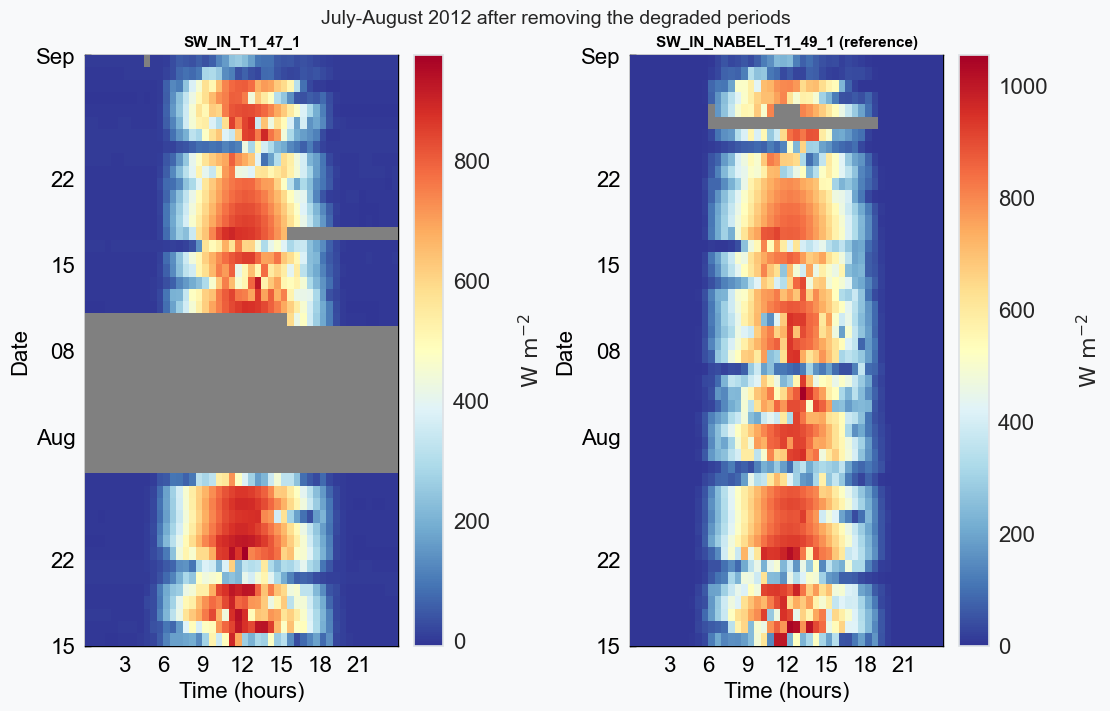

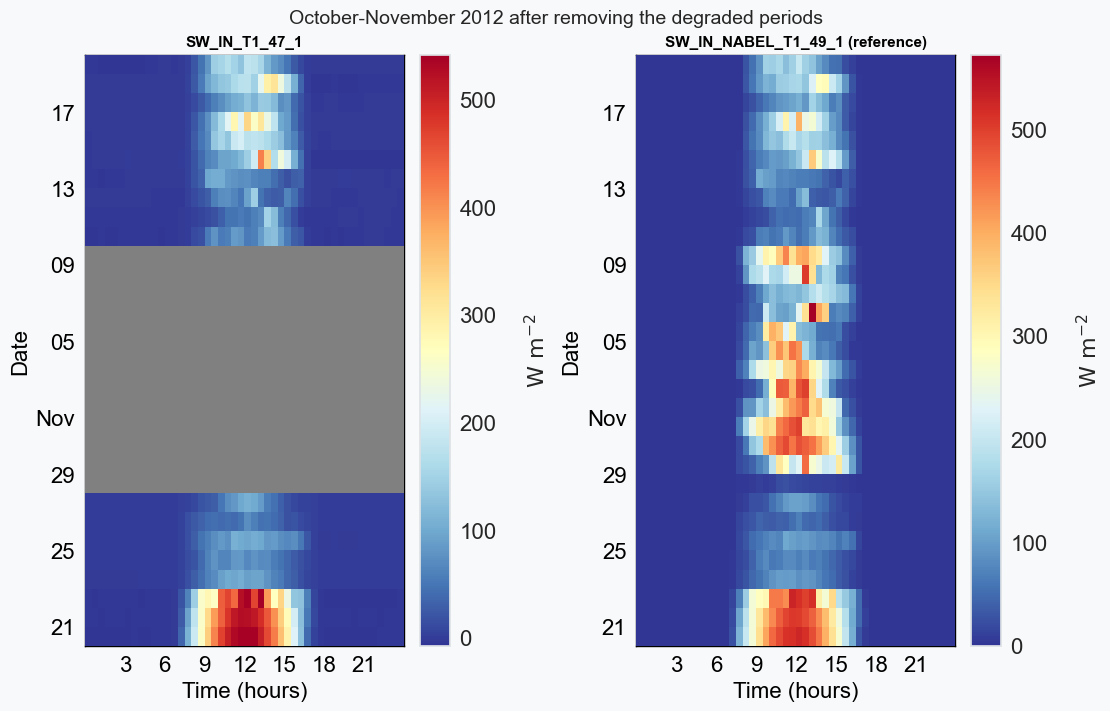

In [17]:
# Three damaged periods in 2012, all documented in the fieldbook and none repairable.
# Windows are on the CORRECTED time axis (i.e. after the +15.5 h shift above).
BAD_WINDOWS_2012 = [
    ('2012-07-29 00:00', '2012-08-10 15:30'),  # tower power supply failure (fieldbook 09.08.2012)
    ('2012-08-17 15:30', '2012-08-18 00:00'),  # transitional tail after the last shifted value
    ('2012-10-28 00:00', '2012-11-10 00:00'),  # storm damage, stressed cables (fieldbook 01./06.11.2012)
]
DEGRADED_VAR = 'SW_IN_T1_47_1'

_before = int(swin_2004_2025[DEGRADED_VAR].notna().sum())
for _start, _end in BAD_WINDOWS_2012:
    _locs = (swin_2004_2025.index >= _start) & (swin_2004_2025.index <= _end)
    swin_2004_2025.loc[_locs, DEGRADED_VAR] = np.nan
_removed = _before - int(swin_2004_2025[DEGRADED_VAR].notna().sum())
print(f"Removed {_removed} degraded records from {DEGRADED_VAR} (gap-filled later from NABEL).")

# One heatmap pair per affected period, with the NABEL sensor as the reference.
for _lo, _hi, _label in [('2012-07-15', '2012-09-01', 'July-August'),
                         ('2012-10-20', '2012-11-20', 'October-November')]:
    fig, axs = plt.subplots(ncols=2, figsize=(11, 7), dpi=100, layout="constrained")
    fig.suptitle(f'{_label} 2012 after removing the degraded periods', fontsize=14)
    _show = (swin_2004_2025.index >= _lo) & (swin_2004_2025.index <= _hi)
    dv.plotting.HeatmapDateTime(series=swin_2004_2025.loc[_show, DEGRADED_VAR]).plot(
        ax=axs[0], cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title=DEGRADED_VAR, title_fontsize=11))
    dv.plotting.HeatmapDateTime(series=swin_2004_2025.loc[_show, 'SW_IN_NABEL_T1_49_1']).plot(
        ax=axs[1], cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title='SW_IN_NABEL_T1_49_1 (reference)', title_fontsize=11))

### Nighttime zero-offset correction

A pyranometer reads a small non-zero signal at night. It is an instrument offset, not radiation,
and it drifts, so it is removed per day rather than as one constant. `mst`-screened records carry
a clearly negative offset.

It is done here rather than left to the gap-filler because `correct_nighttime_offset=True`
corrects only the series being filled — its **target**. Series passed through `context_df` are
used as given, and both radiation sensors are drivers. Correcting once, here, covers every use.

::: {.callout-warning title="This correction writes into gaps — capture the mask first"}
`remove_nighttime_zero_offset()` forces **every** nighttime position to zero, `NaN` included. On a
gappy series it therefore fills nighttime gaps with a real value, and every later step reads them
as measured. That is the trap notebook `03` fell into, where it turned 7,543 modelled values into
apparently measured ones.

So the gap mask is taken **before** the correction and restored **after**: the offset goes, a gap
stays a gap.
:::

In [18]:
# Correct both radiation sensors. Lägern is not corrected here -- it is published by
# MeteoSwiss already offset-free (its minimum is exactly 0.0) and we do not alter reference data.
ZERO_OFFSET_VARS = ['SW_IN_T1_47_1', 'SW_IN_NABEL_T1_49_1']

_summary = []
for _var in ZERO_OFFSET_VARS:
    _series = swin_2004_2025[_var]

    # Capture the gap mask BEFORE correcting: the correction writes zeros into
    # nighttime NaNs and would otherwise turn gaps into apparent measurements.
    _gaps_before = _series.isna()

    _res = dv.corrections.nighttime_zero_offset_diagnostics(
        series=_series,
        lat=SITE_LAT,
        lon=SITE_LON,
        utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
    )

    _corrected = _res.corrected.copy()
    _corrected[_gaps_before] = np.nan  # restore the gaps the correction just filled

    # The correction must not have invented or destroyed data.
    assert _corrected.isna().equals(_gaps_before), f'{_var}: gap structure changed'

    swin_2004_2025[_var] = _corrected
    _summary.append({
        'variable': _var,
        'n_gaps': int(_gaps_before.sum()),
        'below_zero_before': _res.n_below_zero_before,
        'below_zero_before_night': _res.n_below_zero_before_night,
        'below_zero_after': int((_corrected < 0).sum()),
        'offset_min': round(float(_res.offset.min()), 3),
        'offset_max': round(float(_res.offset.max()), 3),
    })

pd.DataFrame(_summary).set_index('variable')

,n_gaps,below_zero_before,below_zero_before_night,below_zero_after,offset_min,offset_max
variable,,,,,,
SW_IN_T1_47_1,34002,133876,128454,0,-13.467,18.690
SW_IN_NABEL_T1_49_1,122954,0,0,0,0.000,0.184


#### Check: nighttime is zero and nothing is negative

The correction is only useful if it actually held, so it is asserted rather than assumed. Both
conditions are checked on measured records only — gaps are still gaps at this point and are filled
later.

In [19]:
# Rebuild the day/night split independently of the correction, from the site coordinates,
# so this is a real check and not a restatement of what the correction just did.
_dnf = dv.variables.DaytimeNighttimeFlag(
    timestamp_index=swin_2004_2025.index,
    nighttime_threshold=0.001,
    lat=SITE_LAT,
    lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
)
_is_night = _dnf.get_nighttime_flag() == 1
print(f"Nighttime records: {int(_is_night.sum()):,} of {len(swin_2004_2025):,}")

for _var in ZERO_OFFSET_VARS:
    _s = swin_2004_2025[_var]
    _measured = _s.notna()
    _night_vals = _s[_is_night & _measured]
    _n_negative = int((_s[_measured] < 0).sum())
    _n_night_nonzero = int((_night_vals != 0).sum())
    print(f"  {_var:<24s} negatives: {_n_negative:>6,}   nighttime non-zero: {_n_night_nonzero:>6,}")
    assert _n_negative == 0, f'{_var}: {_n_negative} negative values remain after correction'
    assert _n_night_nonzero == 0, f'{_var}: {_n_night_nonzero} nighttime values are not zero'

print("\nOK: no negatives, and every measured nighttime record is exactly zero.")

Nighttime records: 184,260 of 385,728
  SW_IN_T1_47_1            negatives:      0   nighttime non-zero:      0
  SW_IN_NABEL_T1_49_1      negatives:      0   nighttime non-zero:      0

OK: no negatives, and every measured nighttime record is exactly zero.


### Dataframe

In [20]:
display(swin_2004_2025)
swin_2004_2025.describe()

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,0.0
2004-01-01 00:45:00,NaN,0.0
2004-01-01 01:15:00,NaN,0.0
2004-01-01 01:45:00,NaN,0.0
2004-01-01 02:15:00,NaN,0.0
...,...,...
2025-12-31 21:45:00,0.0,NaN
2025-12-31 22:15:00,0.0,NaN
2025-12-31 22:45:00,0.0,NaN


,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
count,351726.000000,262774.000000
mean,145.103354,140.035108
std,239.663239,233.702051
min,0.000000,0.000000
25%,0.000000,0.000000
50%,3.677069,2.495635
75%,195.487633,186.456335
max,1118.658439,1236.721293


***

***
## 🌍 Reference: MeteoSwiss Lägern

`SW_IN` is the position of the sun multiplied by the state of the sky. `SW_IN_POT` and the
timestamp give the first factor exactly; only a second radiation measurement gives the second.
NABEL was that measurement, and it **stops in 2018**.

MeteoSwiss Lägern is 2.5 km from the tower on the same ridge at 845 m and covers the whole record,
so it is a driver in both gap-filling runs and the only one after 2018.

It is a **driver, not a replacement**: it never overwrites a measured value, and the exported
series is always the tower sensor.

::: {.callout-note title="Timestamp conversion"}
The reference carries `TIMESTAMP_END`; this notebook works on `TIMESTAMP_MID`. For 30MIN data the
bin `(t-30min, t]` has its midpoint at `t-15min`, so the reference index is shifted back by 15
minutes. The guard below proves the alignment instead of assuming it.
:::

In [21]:
swin_ref = pd.read_parquet(REFPATH)[[REFCOL]]
print(f"Reference read: {len(swin_ref):,} records, "
      f"{swin_ref.index[0]} -> {swin_ref.index[-1]} ({swin_ref.index.name})")

# TIMESTAMP_END -> TIMESTAMP_MID: the 30MIN bin (t-30min, t] has its midpoint at t-15min.
swin_ref.index = swin_ref.index - pd.Timedelta(minutes=15)
swin_ref.index.name = swin_2004_2025.index.name

# Guard: the shift must be right. Correlating the reference against the *measured* tower series
# at several half-hour offsets has to pick offset 0. A silently mis-shifted driver would teach
# the model the wrong sky state and there would be nothing in the output to show it.
_meas = swin_2004_2025['SW_IN_T1_47_1']
_scores = {}
for _off in (-1, 0, 1):
    _j = pd.concat([_meas.rename('t'), swin_ref[REFCOL].shift(_off).rename('r')], axis=1).dropna()
    _j = _j[_j['r'] > 20]  # daytime only: at night both are ~0 and carry no timing information
    _scores[_off] = _j['t'].corr(_j['r'])
    print(f"  offset {_off:+d} x 30min: daytime corr {_scores[_off]:.4f}")
assert max(_scores, key=_scores.get) == 0, f"reference is mis-aligned: {_scores}"
print("OK: offset 0 wins, the TIMESTAMP_MID conversion is correct.")

swin_2004_2025 = swin_2004_2025.join(swin_ref, how='left')
print(f"\nMerged. {REFCOL} available for "
      f"{swin_2004_2025[REFCOL].notna().mean() * 100:.2f}% of records "
      f"({swin_2004_2025[REFCOL].isna().sum():,} missing)")
swin_2004_2025[['SW_IN_T1_47_1', REFCOL]].describe().round(2)

Reference read: 384,241 records, 2004-02-01 01:00:00 -> 2026-01-01 01:00:00 (TIMESTAMP_END)
  offset -1 x 30min: daytime corr 0.9288
  offset +0 x 30min: daytime corr 0.9648
  offset +1 x 30min: daytime corr 0.9069
OK: offset 0 wins, the TIMESTAMP_MID conversion is correct.

Merged. SW_IN_LAE_MS available for 99.58% of records (1,602 missing)


,SW_IN_T1_47_1,SW_IN_LAE_MS
count,351726.00,384126.00
mean,145.10,141.51
std,239.66,231.39
min,0.00,0.00
25%,0.00,2.00
50%,3.68,5.33
75%,195.49,189.33
max,1118.66,1155.33


## 🟪 Prepare dataframes

Split into the two periods that are gap-filled separately: **2004-2018**, where NABEL and Lägern
are both available as drivers, and **2019-2025**, where NABEL has stopped and Lägern is the only
one. `SW_IN_NABEL_T1_49_1` is dropped from the second frame because it is empty there.

In [22]:
swin_2004_2018 = swin_2004_2025.loc[swin_2004_2025.index.year <= 2018].copy()
swin_2004_2018

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1,SW_IN_LAE_MS
TIMESTAMP_MIDDLE,,,
2004-01-01 00:15:00,NaN,0.0,NaN
2004-01-01 00:45:00,NaN,0.0,NaN
2004-01-01 01:15:00,NaN,0.0,NaN
2004-01-01 01:45:00,NaN,0.0,NaN
2004-01-01 02:15:00,NaN,0.0,NaN
...,...,...,...
2018-12-31 21:45:00,0.0,0.0,2.000000
2018-12-31 22:15:00,0.0,0.0,2.000000
2018-12-31 22:45:00,0.0,0.0,2.000000


In [23]:
swin_2019_2025 = swin_2004_2025.loc[swin_2004_2025.index.year >= 2019].copy()
swin_2019_2025 = swin_2019_2025.drop('SW_IN_NABEL_T1_49_1', axis=1)
swin_2019_2025

,SW_IN_T1_47_1,SW_IN_LAE_MS
TIMESTAMP_MIDDLE,,
2019-01-01 00:15:00,0.0,2.333333
2019-01-01 00:45:00,0.0,2.000000
2019-01-01 01:15:00,0.0,2.000000
2019-01-01 01:45:00,0.0,2.000000
2019-01-01 02:15:00,0.0,2.000000
...,...,...
2025-12-31 21:45:00,0.0,2.333333
2025-12-31 22:15:00,0.0,2.000000
2025-12-31 22:45:00,0.0,1.666667


***

## 🟥 Gap-filling ETH (2004-2018)
- Drivers: NABEL (49 m, same tower) and MeteoSwiss Lägern, both as measured

`SWINGapFillerXGBoost` computes `SW_IN_POT` from the site coordinates, uses it to split day from
night, sets nighttime gaps to zero and fills daytime gaps with XGBoost. Negatives are clipped
internally, and `correct_nighttime_offset=True` finds nothing left to remove because the offset
was taken out above.

**Both drivers enter as measured**, so the target never partly predicts itself. NABEL is gappy;
Lägern covers those gaps at 99.6% presence. Where *both* are missing the gap-filler falls back to
a timestamp-only model and marks the record **flag 2** — that flag is the count of half-hours
where this happened.

**Short daytime gaps** (up to 1 h) can be interpolated from the neighbours instead of modelled,
which is only the better option when no second radiation sensor exists. Lägern is present in both
runs, so `interpolate_short_gaps='auto'` resolves to *off* in both.

| Run | Drivers (`context_df`) |
|---|---|
| ETH 2004-2018 | NABEL (measured) + Lägern |
| ETH 2019-2025 | Lägern |

### Run gap-filling

`SW_IN_POT` and the timestamp features are added by the gap-filler itself; `context_df` supplies
the two independent radiation measurements.

NABEL sits at 49 m on the same tower and is the closer of the two, but stops in 2018 and has gaps
of its own. Lägern is 2.5 km away and continuous. Between them the model almost always sees a real
sky state rather than only the time of day.

In [24]:
%%time

TARGET = "SW_IN_T1_47_1"

gf_eth_2004_2018 = dv.gapfilling.SWINGapFillerXGBoost(
    series=swin_2004_2018[TARGET],
    lat=SITE_LAT,
    lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
    # Both drivers as measured. NABEL is gappy; Lägern (99.6% present) covers those gaps,
    # so neither the tower nor a model-filled series is used to predict the tower.
    context_df=swin_2004_2018[['SW_IN_NABEL_T1_49_1', REFCOL]],
    correct_nighttime_offset=True,
    # interpolate_short_gaps left at 'auto': drivers are given, so interpolation stays OFF
    reduce_features=True,
    verbose=1,
    # XGBoost hyperparameters are left at the class defaults (n_estimators, max_depth,
    # early_stopping_rounds, random_state). They are tuned for SW_IN and keep a run
    # reproducible; only n_jobs is set here.
    n_jobs=-1,
)
gf_eth_2004_2018.run()

──────────────────────────────── SW_IN Gap-Filling (SW_IN_T1_47_1) ─────────────────────────────────

> running remove_nighttime_zero_offset ...

Output()

> Step 1: Correcting nighttime sensor offset (2.0s)

Output()

...

> Step 6: Reducing features (SHAP vs random benchmark) and retraining (2.1s)

Output()

> Step 7: Filling daytime gaps (SHAP importances over full record) (9.3s)

v Done in 18.0s - 33155 records filled (33155 gaps total)

CPU times: total: 1min 12s
Wall time: 18 s


### Report

In [25]:
gf_eth_2004_2018.report()

───────────────────────────── SW_IN Gap-Filling Report: SW_IN_T1_47_1 ──────────────────────────────

Algorithm: physics-aware partitioning + XGBoost
    Nighttime gaps  -> set to 0 W m-2 (no incoming solar radiation)
    Daytime gaps    -> XGBoost trained on daytime observations
    Day/night split -> SW_IN_POT (potential radiation) vs threshold

──────────────────────────────────────────── Parameters ────────────────────────────────────────────

Site latitude              47.478333
  Site longitude             8.364389
  UTC offset                 1
  Nighttime threshold        0.001 W m-2  (SW_IN_POT < threshold -> night)
  Correct nighttime offset   True
  Reduce features (SHAP)     True
  context drivers            ['SW_IN_NABEL_T1_49_1', 'SW_IN_LAE_MS']

─────────────────────────────────────── Feature engineering ────────────────────────────────────────

...

MSE      868.2587

RMSE     29.4662

MAPE     64473181249663.6094

MAXE     729.3863

R2       0.9879

### Results: scores and feature importances

In [26]:
r = gf_eth_2004_2018.results
print("Daytime model, held-out (train/test) scores:")
display(pd.Series(r.scores_traintest))
print("Flag counts:")
display(r.flag.value_counts().sort_index().rename(index=FLAG_LEGEND))

Daytime model, held-out (train/test) scores:


mae      1.612012e+01
medae    6.344359e+00
mse      1.082076e+03
rmse     3.289493e+01
mape     5.887277e+13
maxe     6.607116e+02
r2       9.847740e-01
dtype: float64

Flag counts:


flag
0 = observed                                                                           229837
1 = daytime gap, filled by the XGBoost model                                            17011
2 = daytime gap, filled by the timestamp-only fallback model (a driver was missing)       697
3 = nighttime gap, set to zero by physics                                               15447
Name: count, dtype: int64

In [27]:
r.feature_importances

,SHAP_IMPORTANCE,SHAP_SD
SW_IN_NABEL_T1_49_1,203.099503,132.247116
SW_IN_LAE_MS,11.639704,8.465756
.SW_IN_NABEL_T1_49_1_ROLLMEDIAN4,7.505960,6.374772
.SW_IN_NABEL_T1_49_1_MEAN4,5.144228,3.136867
.SW_IN_LAE_MS_MEAN4,3.874487,6.337811
...,...,...
.SW_IN_NABEL_T1_49_1_SD8,0.742543,0.863851
.WEEK_SIN,0.625209,0.687767
.DOY_SIN,0.611421,1.062662
.SW_IN_LAE_MS_SD8,0.576087,0.910506


### Add gap-filled series to dataframe

In [28]:
gapfilled_eth_2004_2018 = gf_eth_2004_2018.results.gapfilled.rename(f"{TARGET}_gfXG")
swin_2004_2018[gapfilled_eth_2004_2018.name] = gapfilled_eth_2004_2018

# This flag IS exported (see the export section). Held as a standalone series rather than a
# dataframe column so the plotting cells below keep showing radiation only.
flag_eth_2004_2018 = gf_eth_2004_2018.results.flag.rename(f"FLAG_{TARGET}_ISFILLED")
display(flag_eth_2004_2018.value_counts().sort_index().rename(index=FLAG_LEGEND))

swin_2004_2018[[TARGET, gapfilled_eth_2004_2018.name]].describe()

FLAG_SW_IN_T1_47_1_ISFILLED
0 = observed                                                                           229837
1 = daytime gap, filled by the XGBoost model                                            17011
2 = daytime gap, filled by the timestamp-only fallback model (a driver was missing)       697
3 = nighttime gap, set to zero by physics                                               15447
Name: count, dtype: int64

,SW_IN_T1_47_1,SW_IN_T1_47_1_gfXG
count,229837.000000,262992.000000
mean,142.603195,144.261782
std,236.721217,238.046170
min,0.000000,0.000000
25%,0.000000,0.000000
50%,3.657932,4.197031
75%,190.252314,195.239186
max,1111.028655,1111.028655


#### Plot: measured, gap-filled and the fills on their own

The bottom panel shows only the gap-filled values. Anything that looks wrong there — fills at an
implausible level, or a long block of fills — is worth following up, because it is invisible in
the combined series.

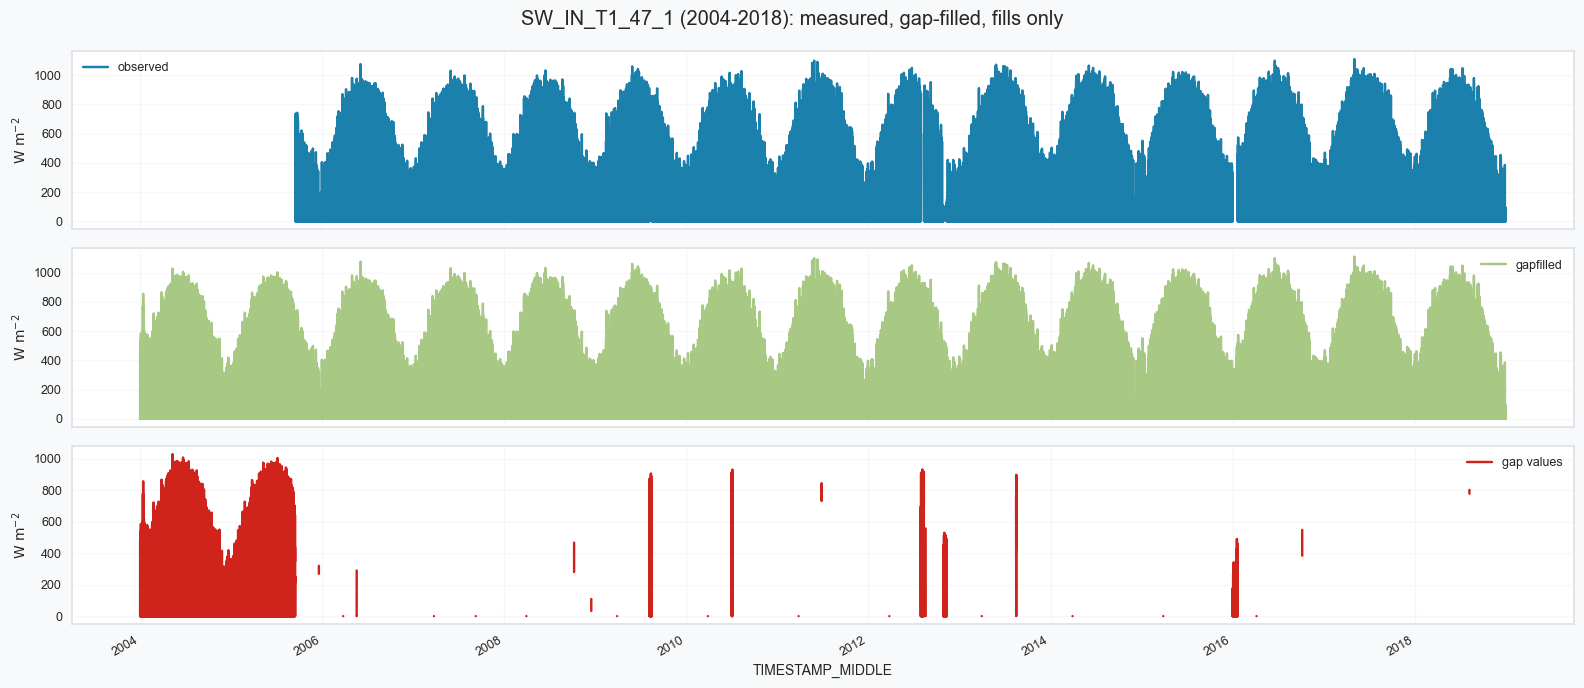

In [29]:
plot_gapfill_panels(gf_eth_2004_2018.results, title="SW_IN_T1_47_1 (2004-2018): measured, gap-filled, fills only");

#### Plot: predicted vs measured on held-out data

The model never saw these records during training, so this is the view that shows whether the
daytime model is actually any good. A tilt in the residual panel means bias; a widening cone means
the error grows with the value, which for radiation is expected.

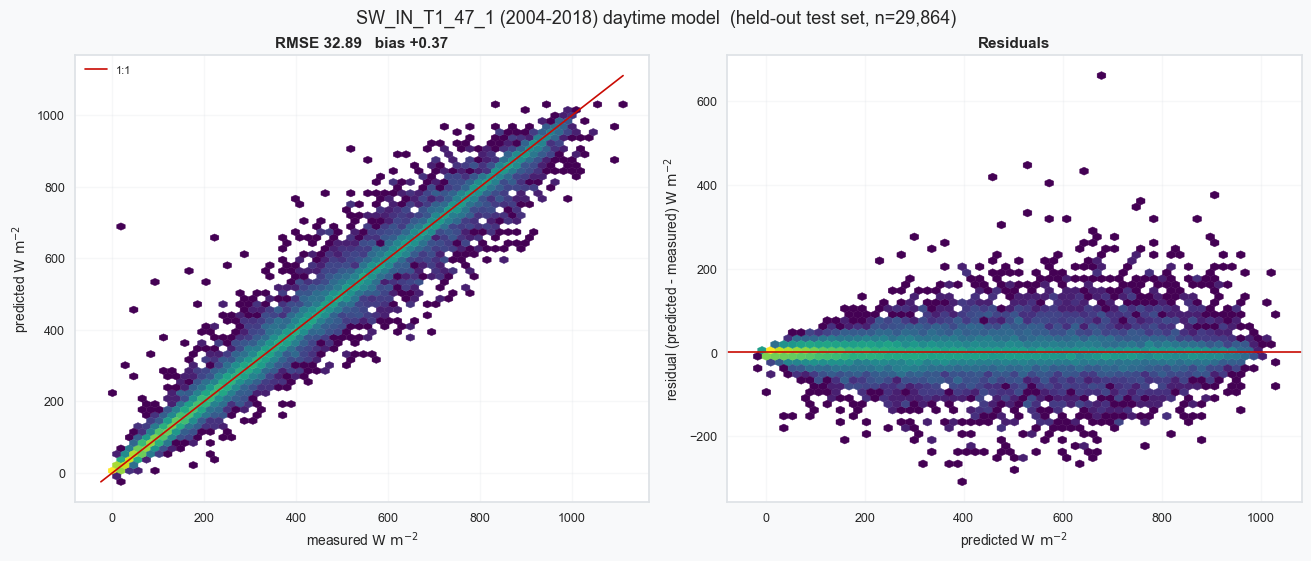

In [30]:
plot_pred_vs_measured(gf_eth_2004_2018.daytime_model_, title="SW_IN_T1_47_1 (2004-2018) daytime model");

### Dataframe

In [31]:
display(swin_2004_2018)
swin_2004_2018.describe()

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1,SW_IN_LAE_MS,SW_IN_T1_47_1_gfXG
TIMESTAMP_MIDDLE,,,,
2004-01-01 00:15:00,NaN,0.0,NaN,0.0
2004-01-01 00:45:00,NaN,0.0,NaN,0.0
2004-01-01 01:15:00,NaN,0.0,NaN,0.0
2004-01-01 01:45:00,NaN,0.0,NaN,0.0
2004-01-01 02:15:00,NaN,0.0,NaN,0.0
...,...,...,...,...
2018-12-31 21:45:00,0.0,0.0,2.000000,0.0
2018-12-31 22:15:00,0.0,0.0,2.000000,0.0
2018-12-31 22:45:00,0.0,0.0,2.000000,0.0


,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1,SW_IN_LAE_MS,SW_IN_T1_47_1_gfXG
count,229837.000000,262774.000000,261392.000000,262992.000000
mean,142.603195,140.035108,139.777236,144.261782
std,236.721217,233.702051,229.285462,238.046170
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,2.000000,0.000000
50%,3.657932,2.495635,5.333333,4.197031
75%,190.252314,186.456335,186.000000,195.239186
max,1111.028655,1236.721293,1155.333333,1111.028655


***

### Plots

#### Heatmap

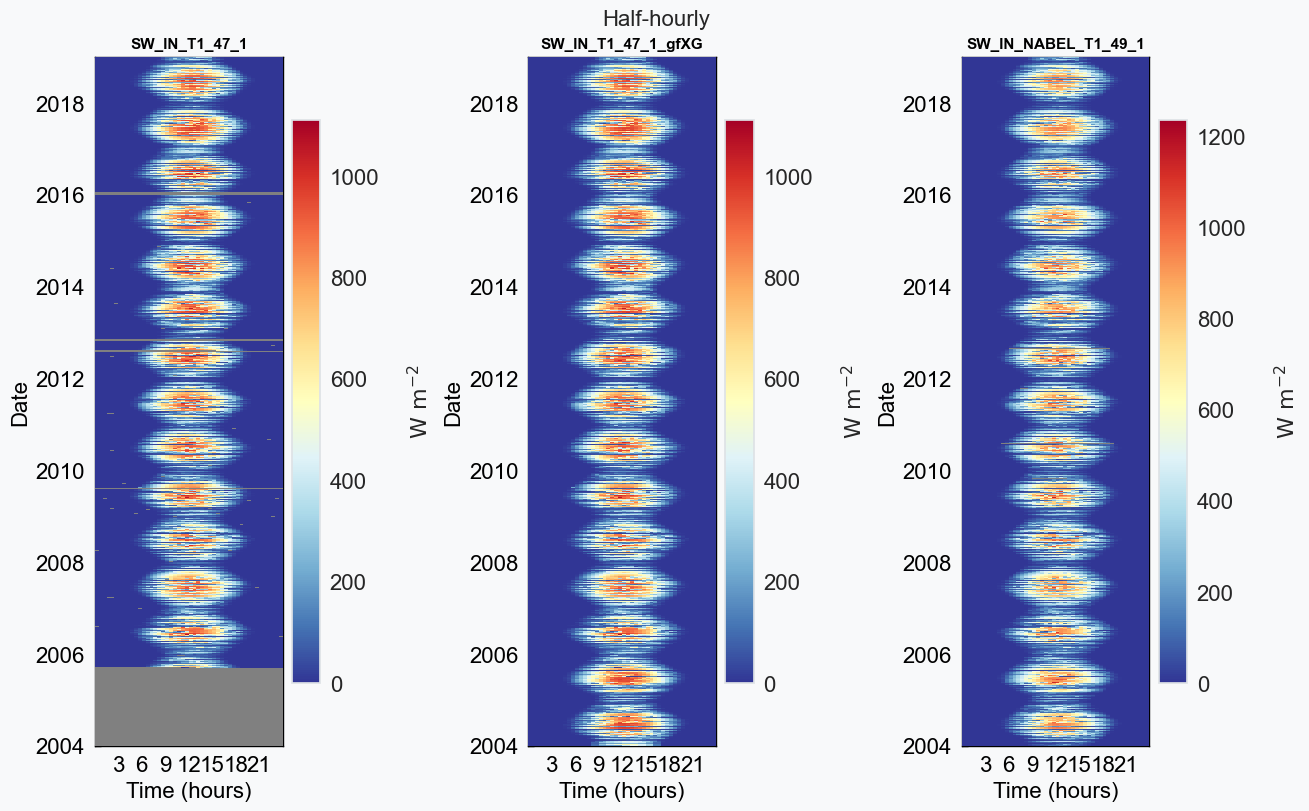

In [32]:
fig, axs = plt.subplots(ncols=3, figsize=(13, 8), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
for _ax, _col in zip(axs, ['SW_IN_T1_47_1', 'SW_IN_T1_47_1_gfXG', 'SW_IN_NABEL_T1_49_1']):
    dv.plotting.HeatmapDateTime(series=swin_2004_2018[_col]).plot(
        ax=_ax, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title=_col, title_fontsize=11))

#### Time series plot

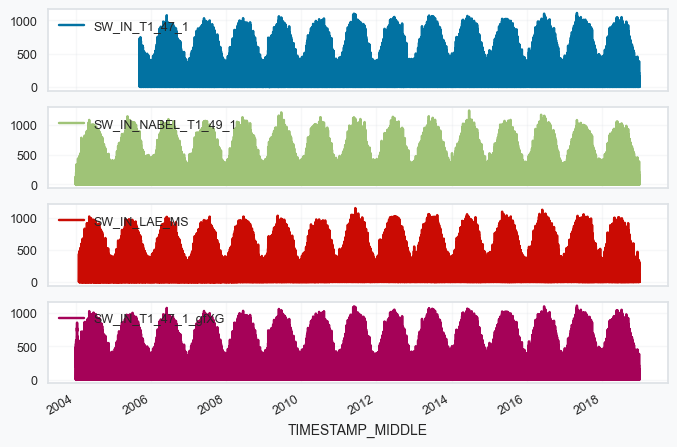

In [33]:
swin_2004_2018.plot(subplots=True, x_compat=True);

***

## 🟧 Gap-filling ETH (2019-2025)
- From mst (2019-2021) and diive meteoscreening (2022-2025)
- NABEL has stopped. **MeteoSwiss Lägern is the only radiation driver.**

::: {.callout-note title="How to read flag 1 in this period"}
Lägern is present for 100% of the filled records here and tracks the tower closely on daytime
half-hours, so these fills follow the actual sky state rather than a typical value for the time of
year.

They are still *estimates from a nearby sensor*: Lägern sits 2.5 km away on the ridge at 845 m,
with its own exposure and a small systematic offset the model has to learn. With one driver
instead of two, flag `1` records here are less certain than their 2004-2018 counterparts.
:::

### Run gap-filling

In [34]:
%%time

TARGET = "SW_IN_T1_47_1"

gf_eth_2019_2025 = dv.gapfilling.SWINGapFillerXGBoost(
    series=swin_2019_2025[TARGET],
    lat=SITE_LAT,
    lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
    context_df=swin_2019_2025[[REFCOL]],  # Lägern: the only radiation driver in this period
    correct_nighttime_offset=True,
    # interpolate_short_gaps left at 'auto'. A driver is now given, so this resolves to OFF
    # and no longer overwrites the model fills, which are now informed by a real sky state.
    reduce_features=True,
    verbose=1,
    # XGBoost hyperparameters are left at the class defaults (n_estimators, max_depth,
    # early_stopping_rounds, random_state). They are tuned for SW_IN and keep a run
    # reproducible; only n_jobs is set here.
    n_jobs=-1,
)
gf_eth_2019_2025.run()

──────────────────────────────── SW_IN Gap-Filling (SW_IN_T1_47_1) ─────────────────────────────────

> running remove_nighttime_zero_offset ...

Output()

> Step 1: Correcting nighttime sensor offset (0.8s)

> Step 2: Computing potential radiation and day/night split (0.7s, 64107 daytime / 58629 nighttime
records)

...

> Step 6: Reducing features (SHAP vs random benchmark) and retraining (2.5s)

Output()

> Step 7: Filling daytime gaps (SHAP importances over full record) (0.8s)

v Done in 6.8s - 847 records filled (847 gaps total)

CPU times: total: 35.1 s
Wall time: 6.85 s


### Report

In [35]:
gf_eth_2019_2025.report()

───────────────────────────── SW_IN Gap-Filling Report: SW_IN_T1_47_1 ──────────────────────────────

Algorithm: physics-aware partitioning + XGBoost
    Nighttime gaps  -> set to 0 W m-2 (no incoming solar radiation)
    Daytime gaps    -> XGBoost trained on daytime observations
    Day/night split -> SW_IN_POT (potential radiation) vs threshold

──────────────────────────────────────────── Parameters ────────────────────────────────────────────

Site latitude              47.478333
  Site longitude             8.364389
  UTC offset                 1
  Nighttime threshold        0.001 W m-2  (SW_IN_POT < threshold -> night)
  Correct nighttime offset   True
  Reduce features (SHAP)     True
  context drivers            ['SW_IN_LAE_MS']

─────────────────────────────────────── Feature engineering ────────────────────────────────────────

...

MSE      2176.4933

RMSE     46.6529

MAPE     144680013012298.0625

MAXE     640.7285

R2       0.9712

### Results: scores and feature importances

In [36]:
r = gf_eth_2019_2025.results
print("Daytime model, held-out (train/test) scores:")
display(pd.Series(r.scores_traintest))
print("Flag counts:")
display(r.flag.value_counts().sort_index().rename(index=FLAG_LEGEND))

Daytime model, held-out (train/test) scores:


mae      2.912316e+01
medae    1.226814e+01
mse      3.108535e+03
rmse     5.575424e+01
mape     1.305378e+14
maxe     6.407285e+02
r2       9.587625e-01
dtype: float64

Flag counts:


flag
0 = observed                                    121889
1 = daytime gap, filled by the XGBoost model       400
3 = nighttime gap, set to zero by physics          447
Name: count, dtype: int64

In [37]:
r.feature_importances

,SHAP_IMPORTANCE,SHAP_SD
SW_IN_LAE_MS,197.179459,123.591957
SW_IN_POT,18.260439,11.492335
.SW_IN_LAE_MS_MEAN4,10.088753,6.276229
.SW_IN_LAE_MS_ROLLMEDIAN4,8.768586,8.276722
.SW_IN_LAE_MS_MEAN8,4.537827,2.573359
.SW_IN_LAE_MS_EMA6,4.373403,3.475349
.YEARDOY,3.911958,3.374832
.HOUR_SIN,3.801167,3.218277
.SW_IN_LAE_MS_ROLLMEDIAN8,3.769056,3.152824
.SW_IN_LAE_MS_MEAN48,3.508657,3.683447


### Add gap-filled series to dataframe

In [38]:
gapfilled_eth_2019_2025 = gf_eth_2019_2025.results.gapfilled.rename(f"{TARGET}_gfXG")
swin_2019_2025[gapfilled_eth_2019_2025.name] = gapfilled_eth_2019_2025

# This flag IS exported (see the export section).
flag_eth_2019_2025 = gf_eth_2019_2025.results.flag.rename(f"FLAG_{TARGET}_ISFILLED")
display(flag_eth_2019_2025.value_counts().sort_index().rename(index=FLAG_LEGEND))

swin_2019_2025[[TARGET, gapfilled_eth_2019_2025.name]].describe()

FLAG_SW_IN_T1_47_1_ISFILLED
0 = observed                                    121889
1 = daytime gap, filled by the XGBoost model       400
3 = nighttime gap, set to zero by physics          447
Name: count, dtype: int64

,SW_IN_T1_47_1,SW_IN_T1_47_1_gfXG
count,121889.000000,122736.000000
mean,149.817717,149.352257
std,245.046332,244.630334
min,0.000000,0.000000
25%,0.000000,0.000000
50%,3.723554,3.638556
75%,205.228608,204.050755
max,1118.658439,1118.658439


#### Plot: measured, gap-filled and the fills on their own

The bottom panel shows only the gap-filled values. Anything that looks wrong there — fills at an
implausible level, or a long block of fills — is worth following up, because it is invisible in
the combined series.

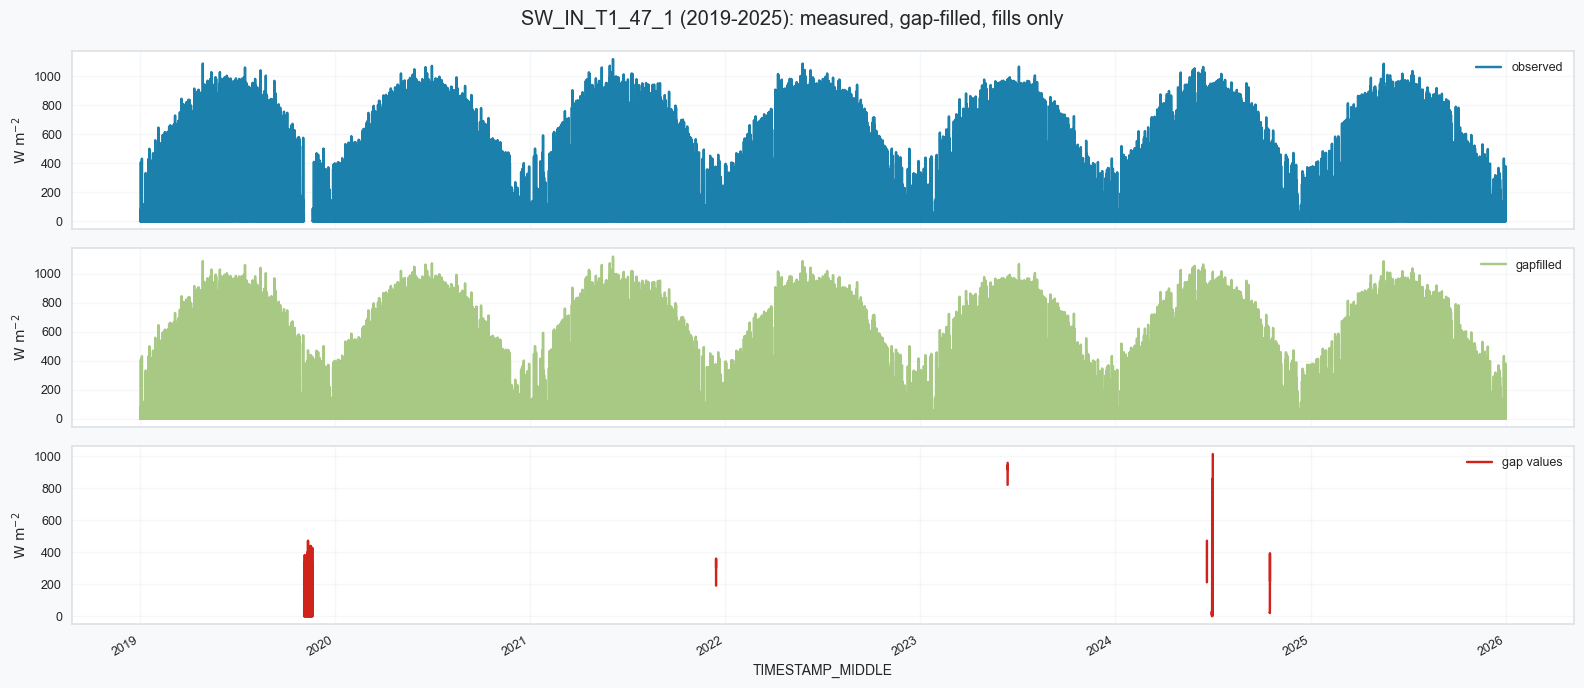

In [39]:
plot_gapfill_panels(gf_eth_2019_2025.results, title="SW_IN_T1_47_1 (2019-2025): measured, gap-filled, fills only");

#### Plot: predicted vs measured on held-out data

The model never saw these records during training, so this is the view that shows whether the
daytime model is actually any good. A tilt in the residual panel means bias; a widening cone means
the error grows with the value, which for radiation is expected.

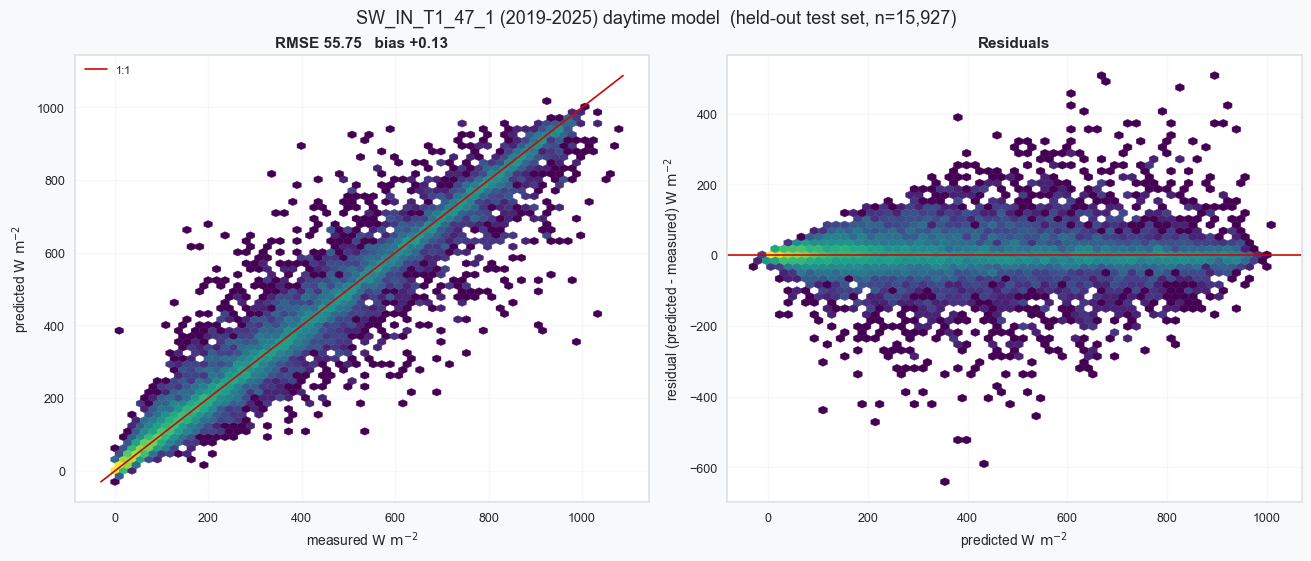

In [40]:
plot_pred_vs_measured(gf_eth_2019_2025.daytime_model_, title="SW_IN_T1_47_1 (2019-2025) daytime model");

### Plot time series

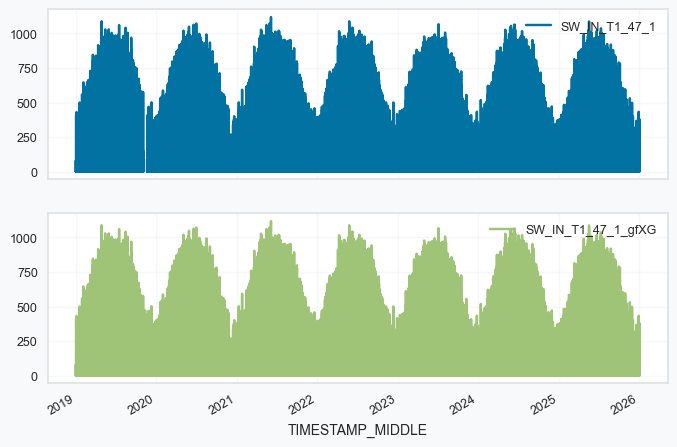

In [41]:
swin_2019_2025[[TARGET, gapfilled_eth_2019_2025.name]].plot(subplots=True, x_compat=True);

### Dataframe

In [42]:
display(swin_2019_2025)
swin_2019_2025.describe()

,SW_IN_T1_47_1,SW_IN_LAE_MS,SW_IN_T1_47_1_gfXG
TIMESTAMP_MIDDLE,,,
2019-01-01 00:15:00,0.0,2.333333,0.0
2019-01-01 00:45:00,0.0,2.000000,0.0
2019-01-01 01:15:00,0.0,2.000000,0.0
2019-01-01 01:45:00,0.0,2.000000,0.0
2019-01-01 02:15:00,0.0,2.000000,0.0
...,...,...,...
2025-12-31 21:45:00,0.0,2.333333,0.0
2025-12-31 22:15:00,0.0,2.000000,0.0
2025-12-31 22:45:00,0.0,1.666667,0.0


,SW_IN_T1_47_1,SW_IN_LAE_MS,SW_IN_T1_47_1_gfXG
count,121889.000000,122734.000000,122736.000000
mean,149.817717,145.210102,149.352257
std,245.046332,235.775359,244.630334
min,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000
50%,3.723554,5.666667,3.638556
75%,205.228608,196.666667,204.050755
max,1118.658439,1136.000000,1118.658439


***

## ➡️ Prepare dataframe for export

In [43]:
VALCOL = "SW_IN_T1_47_1_gfXG"
FLAGCOL = "FLAG_SW_IN_T1_47_1_ISFILLED"

# Values and flags come from the same gap-filling run per period, so they are paired
# before the two periods are stacked.
export_df = pd.concat([
    pd.concat([swin_2004_2018[VALCOL], flag_eth_2004_2018], axis=1),
    pd.concat([swin_2019_2025[VALCOL], flag_eth_2019_2025], axis=1),
], axis=0)
export_df

,SW_IN_T1_47_1_gfXG,FLAG_SW_IN_T1_47_1_ISFILLED
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,0.0,3
2004-01-01 00:45:00,0.0,3
2004-01-01 01:15:00,0.0,3
2004-01-01 01:45:00,0.0,3
2004-01-01 02:15:00,0.0,3
...,...,...
2025-12-31 21:45:00,0.0,0
2025-12-31 22:15:00,0.0,0
2025-12-31 22:45:00,0.0,0


Sanity check: the exported series must be complete (no gaps) and non-negative, the index must be
continuous 30MIN with no duplicates, and every record must carry a flag.

`FLAG_SW_IN_T1_47_1_ISFILLED` travels with the product so the downstream notebooks can tell
measured from filled records. Flag `0` is measured, everything above `0` is filled by the method
given in `FLAG_LEGEND`.

In [44]:
print(f"Records:         {len(export_df)}")
print(f"Missing values:  {export_df[VALCOL].isnull().sum()}")
print(f"Negative values: {(export_df[VALCOL] < 0).sum()}")
print(f"Missing flags:   {export_df[FLAGCOL].isnull().sum()}")
print(f"Duplicate index: {export_df.index.duplicated().sum()}")
print(f"Index gaps:      {(export_df.index.to_series().diff().dropna() != pd.Timedelta('30min')).sum()}")

print("\nFill provenance:")
_counts = export_df[FLAGCOL].value_counts().sort_index()
_pct = 100 * _counts / len(export_df)
display(pd.DataFrame({'count': _counts, '%': _pct.round(2)}).rename(index=FLAG_LEGEND))
print(f"Measured: {100 * (export_df[FLAGCOL] == 0).mean():.2f}%  |  "
      f"Filled: {100 * (export_df[FLAGCOL] > 0).mean():.2f}%")

export_df.describe()

# The exported series is complete, so every nighttime record must be exactly zero --
# not merely non-negative. This is the end-to-end version of the check made before
# gap-filling, and it also covers the values the gap-filler itself wrote.
_dnf_out = dv.variables.DaytimeNighttimeFlag(
    timestamp_index=export_df.index,
    nighttime_threshold=0.001,
    lat=SITE_LAT,
    lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
)
_night_out = _dnf_out.get_nighttime_flag() == 1
_bad_night = int((export_df.loc[_night_out, VALCOL] != 0).sum())
_bad_neg = int((export_df[VALCOL] < 0).sum())
print(f"Nighttime non-zero:  {_bad_night}")
print(f"Negative values:     {_bad_neg}")
assert _bad_night == 0, f'{_bad_night} exported nighttime records are not zero'
assert _bad_neg == 0, f'{_bad_neg} exported records are negative'
print("Nighttime/negativity checks passed.")

Records:         385728
Missing values:  0
Negative values: 0
Missing flags:   0
Duplicate index: 0
Index gaps:      0

Fill provenance:


,count,%
FLAG_SW_IN_T1_47_1_ISFILLED,,
0 = observed,351726,91.18
"1 = daytime gap, filled by the XGBoost model",17411,4.51
"2 = daytime gap, filled by the timestamp-only fallback model (a driver was missing)",697,0.18
"3 = nighttime gap, set to zero by physics",15894,4.12


Measured: 91.18%  |  Filled: 8.82%
Nighttime non-zero:  0
Negative values:     0
Nighttime/negativity checks passed.


### Gap-filling overview

Where the fills sit in the record, and whether they behave like the measured data. In the monthly
means panel the two lines should track each other; a systematic gap between them means the fills
are biased relative to the measurements.

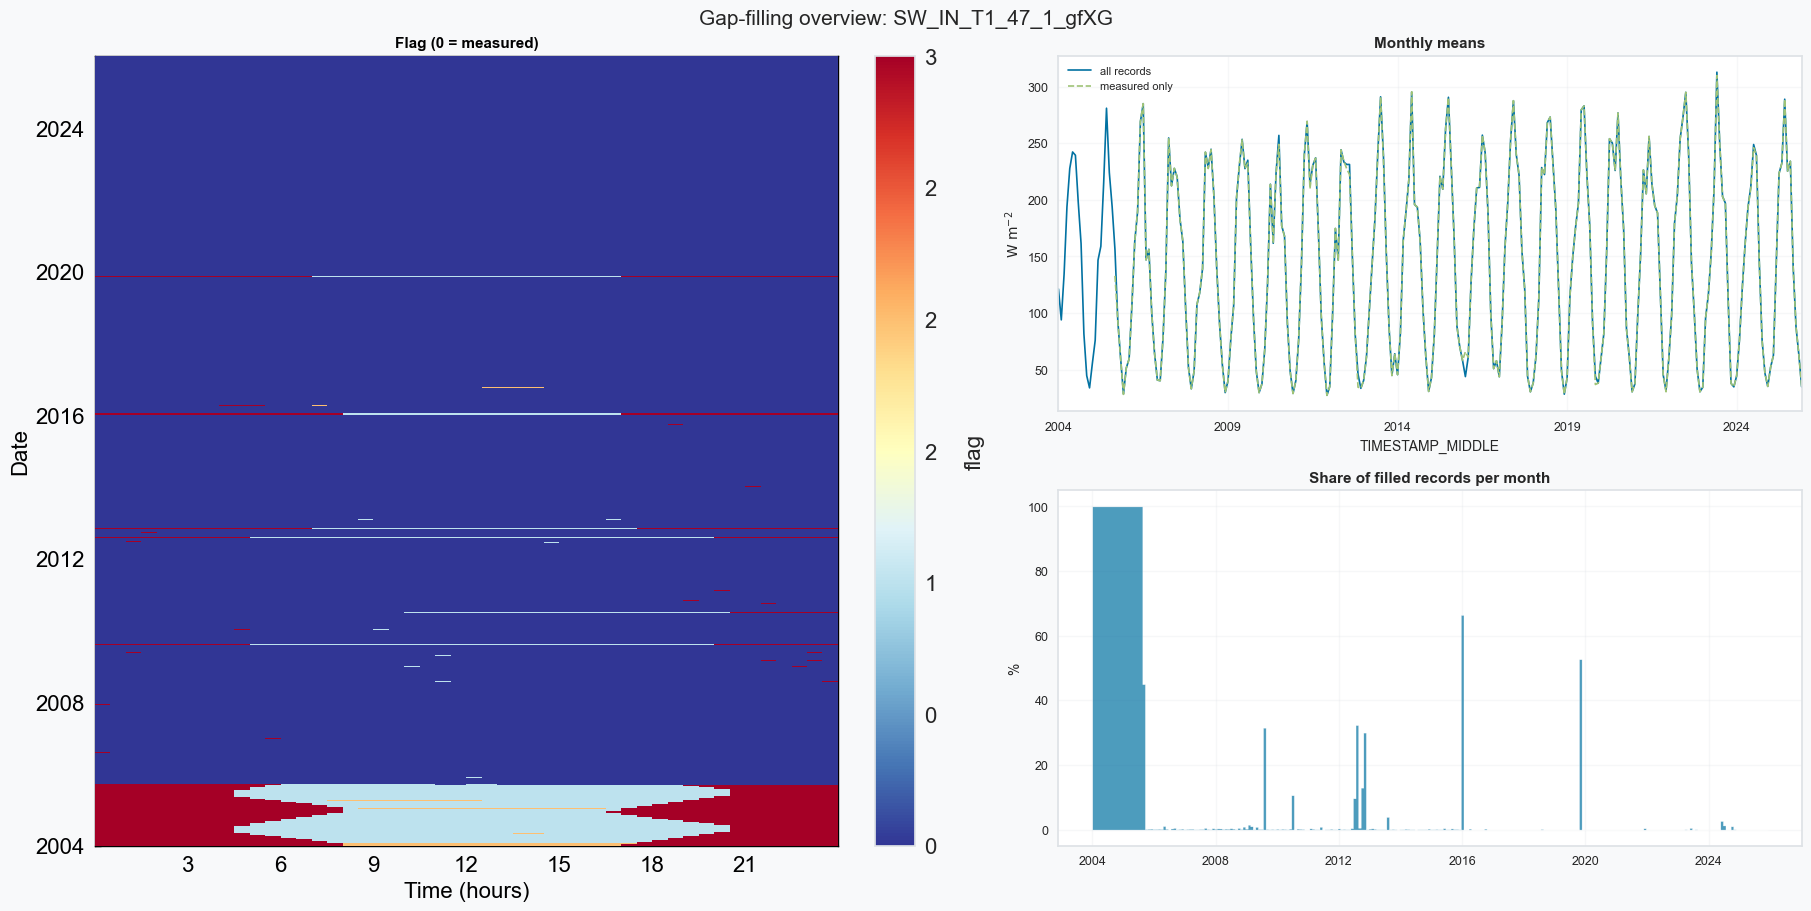

In [45]:
plot_fill_overview(export_df[VALCOL], export_df[FLAGCOL], label=VALCOL);

### Fill statistics per year

The table counts records per year and flag; the bars show the filled ones only. This is where an
uneven distribution of fills across the record becomes obvious.

,0 = observed,"1 = daytime gap, filled by the XGBoost model","2 = daytime gap, filled by the timestamp-only fallback model (a driver was missing)","3 = nighttime gap, set to zero by physics"
year,,,,
2004,0,8571,598,8399
2005,5199,6863,56,5402
2006,17473,17,0,30
2007,17489,15,0,16
2008,17513,27,0,28
2009,16989,310,0,221
2010,17339,119,0,62
2011,17491,8,9,12
2012,16293,637,29,609


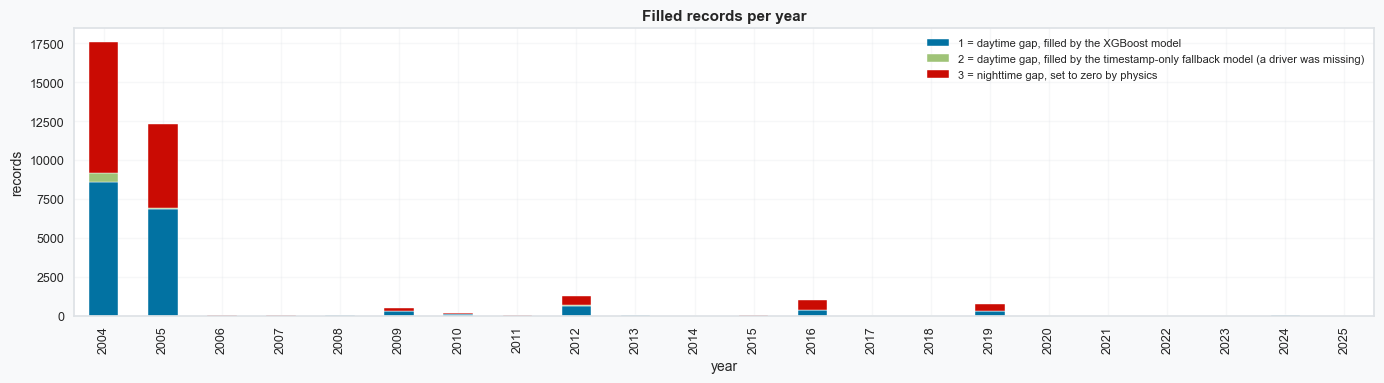

In [46]:
fill_stats_by_year(export_df[FLAGCOL])

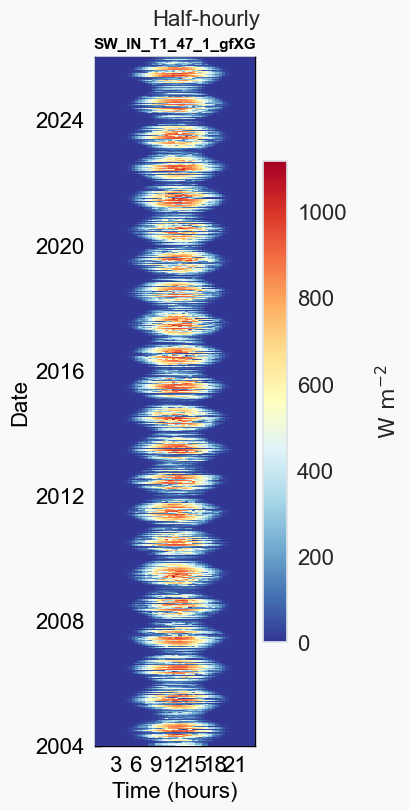

In [47]:
fig, axs = plt.subplots(ncols=1, figsize=(4, 8), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.plotting.HeatmapDateTime(series=export_df[VALCOL]).plot(
    ax=axs, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
    format_style=dv.plotting.FormatStyle(title=VALCOL, title_fontsize=11))

***

## 💾 Save to file

In [48]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\01_METEO_SW_IN_GAPFILLED_2004-2025.parquet (0.049 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS\01_METEO_SW_IN_GAPFILLED_2004-2025.parquet


***

## End of notebook

In [49]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-07-20 22:55:29
Finished: 2026-07-20 22:56:47
Runtime:  00:01:17 (hh:mm:ss)
